In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder 
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_excel('Dataset_Dummy_MBG.xlsx')
print(df.head())

  Periode_Survey    Provinsi Jenis_Sekolah Status_Pelaksanaan Kepuasan_Siswa  \
0        2025-03  Jawa Barat            SD        Sangat Baik    Sangat Puas   
1        2026-01  Jawa Timur            SD               Baik     Cukup Puas   
2        2025-03  Jawa Timur            SD              Cukup    Sangat Puas   
3        2025-07  Jawa Timur           SMP        Sangat Baik           Puas   
4        2025-02  Jawa Barat            SD              Cukup           Puas   

               Kategori_Gizi_Menu  Sumber_Pendanaan  Skor_Gizi  Skor_Kepuasan  \
0  Perlu Peningkatan Sayur & Buah              APBN         90             90   
1       Perlu Peningkatan Protein  Kerjasama Swasta         97             94   
2             Sesuai Standar Gizi              APBN         74             85   
3  Perlu Peningkatan Sayur & Buah              APBN         72             78   
4       Perlu Peningkatan Protein  Kerjasama Swasta         82             77   

   Anggaran_per_Siswa_Rp  
0    

In [ ]:
print('cari data frekuansi pelaksanaan')
freq = df['Status_Pelaksanaan'].value_counts()
persen = df['Status_Pelaksanaan'].value_counts(normalize=True) * 100

hasil = pd.DataFrame({
    'Frekuensi': freq, 
    'Persentase': persen
    })
print(hasil)

cari data frekuansi pelaksanaa
                    Frekuensi  Persentase
Status_Pelaksanaan                       
Baik                      407        40.7
Sangat Baik               287        28.7
Cukup                     199        19.9
Kurang                    107        10.7


In [6]:
print('Crostab Status pelaksanaan vs provinsi')
crosstab = pd.crosstab(df['Provinsi'], df['Status_Pelaksanaan'])
print(crosstab)

Crostab Status pelaksanaan vs provinsi
Status_Pelaksanaan  Baik  Cukup  Kurang  Sangat Baik
Provinsi                                            
Jawa Barat            77     39      20           60
Jawa Tengah           68     37      22           60
Jawa Timur           104     40      26           43
Sulawesi Selatan      80     35      19           61
Sumatera Utara        78     48      20           63


In [7]:
print('Chi Square Test')
chi2, p, dof, expected = chi2_contingency(crosstab)
print(f'Chi2: {chi2}, p-value: {p}, Degrees of Freedom: {dof}')

if p < 0.05:
    print('Hasil: Terdapat hubungan yang signifikan antara Provinsi dan Status Pelaksanaan')
else:
    print('Hasil: Tidak terdapat hubungan yang signifikan antara Provinsi dan Status Pelaksanaan')
    

Chi Square Test
Chi2: 14.59433252627779, p-value: 0.2643740590097158, Degrees of Freedom: 12
Hasil: Tidak terdapat hubungan yang signifikan antara Provinsi dan Status Pelaksanaan


In [8]:
print('clustering berbasis kategori')
df_cluster = df.copy()
label_encoder = LabelEncoder()

for col in df_cluster.select_dtypes(include=['object']).columns:
    df_cluster[col] = label_encoder.fit_transform(df_cluster[col])

x = df_cluster[['Skor_Gizi','Skor_Kepuasan','Anggaran_per_Siswa_Rp']]
kmeans = KMeans(n_clusters=3, random_state=42)
df_cluster['Cluster'] = kmeans.fit_predict(x)

print('Hasil clustering:')
print(df_cluster[['Skor_Gizi','Skor_Kepuasan', 'Anggaran_per_Siswa_Rp', 'Cluster']].head())

clustering berbasis kategori


C:\Users\Asus\AppData\Local\Temp\ipykernel_16856\3245132566.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_cluster.select_dtypes(include=['object']).columns:


Hasil clustering:
   Skor_Gizi  Skor_Kepuasan  Anggaran_per_Siswa_Rp  Cluster
0         90             90                  16963        0
1         97             94                  14633        1
2         74             85                  16438        0
3         72             78                  12195        2
4         82             77                  17356        0


In [9]:
print('Analisis Rata rata kepuasan siswa')
kepuasanSiswa = df.groupby('Kategori_Gizi_Menu')['Skor_Kepuasan'].mean()
print(kepuasanSiswa)

Analisis Rata rata kepuasan siswa
Kategori_Gizi_Menu
Perlu Peningkatan Protein         81.950617
Perlu Peningkatan Sayur & Buah    82.139053
Sesuai Standar Gizi               81.857988
Name: Skor_Kepuasan, dtype: float64


EDA kepuasan wilayah


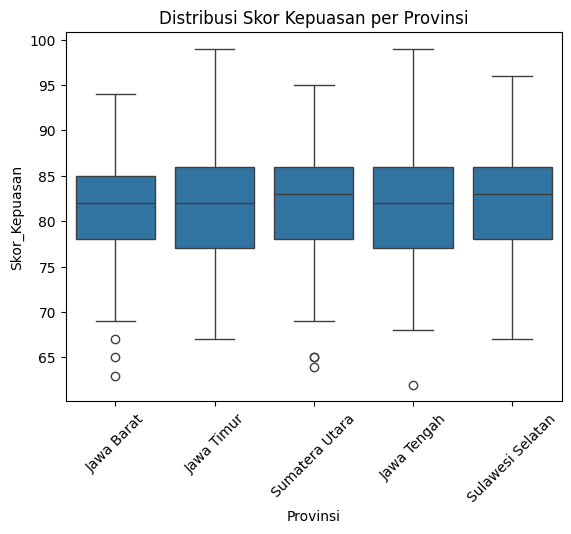

In [36]:
print('EDA kepuasan wilayah')
plt.figure()
sns.boxplot(x='Provinsi', y='Skor_Kepuasan', data=df)
plt.title('Distribusi Skor Kepuasan per Provinsi')
plt.xticks(rotation=45)
plt.show()

Hubungan kualitas Makanan vs Kepuasan


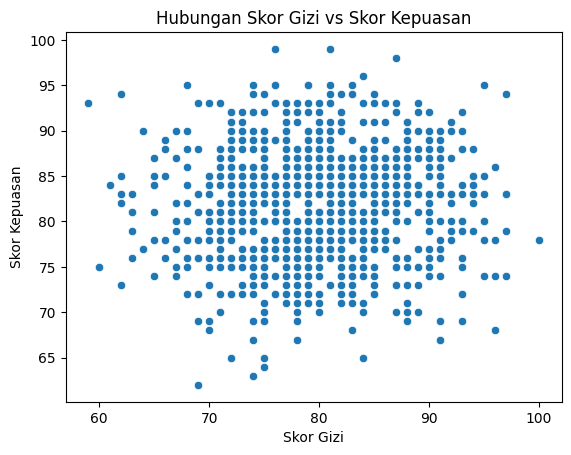

In [ ]:
print('Hubungan kualitas Makanan vs Kepuasan')
plt.figure()
sns.scatterplot(x='Skor_Gizi', y='Skor_Kepuasan', data=df)
hub_makan = df.groupby('Skor_Gizi')['Skor_Kepuasan']


plt.title('Hubungan Skor Gizi vs Skor Kepuasan')
plt.xlabel('Skor Gizi')
plt.ylabel('Skor Kepuasan')
plt.show()

Evaluasi ketetapan waktu


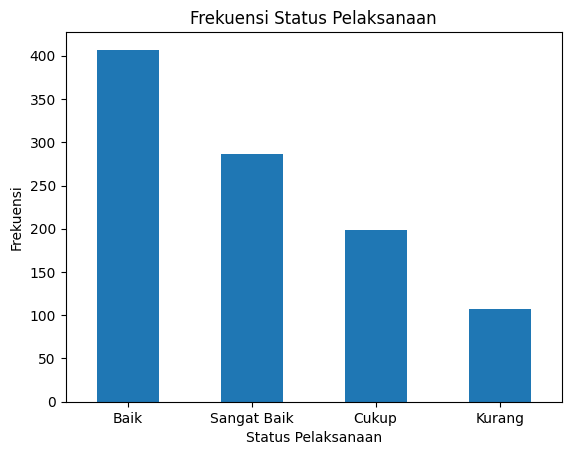

In [ ]:
print('Evaluasi ketetapan waktu')
ket_waktu = df['Status_Pelaksanaan'].value_counts()
plt.figure()
ket_waktu.plot(kind='bar')


plt.title('Frekuensi Status Pelaksanaan')
plt.xlabel('Status Pelaksanaan')
plt.ylabel('Frekuensi')
plt.xticks(rotation=0)
plt.show()

Monitoring Status program
Status monitoring 
Status_Pelaksanaan  Baik  Cukup  Kurang  Sangat Baik
Periode_Survey                                      
2025-01               37     19       5           18
2025-02               37     15       7           25
2025-03               19     13      11           24
2025-04               37     19       3           33
2025-05               26     17       7           25
2025-06               35     13      10           18
2025-07               27     16      13           18
2025-08               45     15      12           30
2025-09               31     10       6           22
2025-10               30     18      14           18
2025-11               28      9      10           20
2025-12               32     19       6           18
2026-01               23     16       3           18


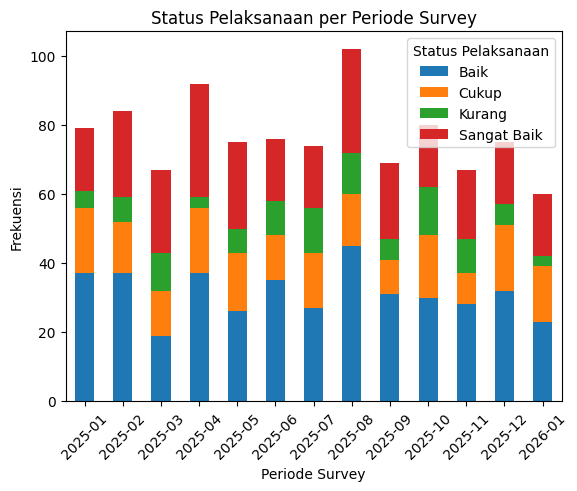

In [39]:
print('Monitoring Status program')
status_prog =  pd.crosstab(df['Periode_Survey'], df['Status_Pelaksanaan'])
print('Status monitoring ')
print(status_prog)

status_prog.plot(kind='bar', stacked=True)
plt.title('Status Pelaksanaan per Periode Survey')
plt.xlabel('Periode Survey')
plt.ylabel('Frekuensi')
plt.xticks(rotation=45)
plt.legend(title='Status Pelaksanaan')
plt.show()